In [1]:
# Trying new package structure
# Basic ECTS/SPRT, exploring laga with betagamma stepper

# %%

import torch
import torch.optim as optim

import pandas as pd
import numpy as np

import sys
from tqdm import tqdm
import time

from pyseqdx.utilities.gen_data_cgm import get_cgm
from pyseqdx.utilities.gen_ar import dict2loader
from pyseqdx.utilities.misc import snake_grid
import pyseqdx.utilities as utilities

import pyseqdx.sequential_models as mdls
import pyseqdx.classifier as ects
import pyseqdx.trainer as trainer

from utilis_fn import *
from mdl_configr import *
import simple_configr as configr


def parse_simu_args(*args, **kwargs):
    # Create the parser

    parser = configr.ConfigParser(description="CGM example.")
    dat_config = parser.add_argument_group("CGM specific config")
    dat_config.add_argument(
        "--window_hours",
        type=float,
        default=1,
        help="duration (in hour) of monitoring window",
    )
    dat_config.add_argument(
        "--how_soon_hours",
        type=float,
        default=0.5,
        help=(
            "maximum time between the end of monitoring window to event onset"
            " for such monitoring window to be labeled positive."
        ),
    )
    dat_config.add_argument(
        "--event_free_window",
        type=str,
        default="y",
        choices=["n", "y"],
        help="whether monitoring window should be event free.",
    )
    dat_config.add_argument(
        "--event_later_than",
        type=float,
        default=0.75,
        help=(
            "event no earlier than window_hours * event_later_than in a window"
            "only matter when event_free_window = n"
        ),
    )
    dat_config.add_argument(
        "--n_samples",
        type=int,
        default=5120,
        help=(
            f"number of total time series to sample. "
            f"Then train/validate/test split 70:10:20."
        ),
    )
    dat_config.add_argument(
        "--event_ratio", type=float, default=0.3, help="Proportion of positive cases."
    )

    # print("we are here")
    # Parse the arguments
    args = parser.parse_args(*args, **kwargs)
    # print
    configr.print_parsed_arg(args)

    return args


def gen_data(args, use_device=None):

    if use_device is None:
        use_device = configr.get_device_to_use(args)

    # Data generation ----------------------------------------------------------

    torch.set_default_device("cpu")
    torch.manual_seed(args.seed)
    np.random.seed(args.seed)
    event_free_window = True if args.event_free_window == "y" else False
    ls_dat = get_cgm(
        args.n_samples,
        args.event_ratio,
        args.window_hours,
        args.how_soon_hours,
        event_free_window,
        args.event_later_than,
    )  # a list of train, validate, and test
    torch.set_default_device(use_device)
    for i in range(len(ls_dat)):
        ls_dat[i] = [
            tm.to(use_device) if isinstance(tm, torch.Tensor) else tm
            for tm in ls_dat[i]
        ]

    dict_dat = {}
    dict_loader = {}
    for partition, ls_this_partition in zip(["train", "validate", "test"], ls_dat):
        dict_this_partition = {
            "x": ls_this_partition[0],
            "y": ls_this_partition[1],
            "misc": ls_this_partition[2],
        }
        dict_dat[partition] = dict_this_partition
        dict_loader[partition] = dict2loader(
            dict_this_partition,
            args.batch_size,
            shuffle=True if partition != "test" else False,
            generator=torch.Generator(device=use_device),
        )
    return dict_dat, dict_loader

In [2]:
# args = parse_simu_args()
args = parse_simu_args(
    [
        "--n_samples",
        "8192",
        "--seed",
        "3",
        "--mu_arch",
        "gru",
        "--nu_arch",
        "gru_simple",
        "--lr",
        "0.005",  # ok
        "--laga_minlr",
        "0.0005",
        "--laga_lrsch",
        "plateau",
        "--min_epoch",
        "50",
        "--max_epoch",
        "600",
        "--desired_tpr",
        "0.95",
        "--desired_cost",
        "0.7",
        "--nulaga_routine",
        "warmup",
        "altstep",
        "--laga_deadzone",
        "0.01",
        "--desired_tol",
        "0.01",
        "--classifier",
        "ects"
    ]
)

Parsed command line arguments:
  cost_scale: 1.0
  seed: 3
  desired_tpr: [0.95]
  desired_cost: [0.7]
  n_grid: 11
  batch_size: 512
  min_epoch: 50
  max_epoch: 600
  lr: 0.005
  laga_lrsch: plateau
  laga_minlr: 0.0005
  nulaga_routine: ['warmup', 'altstep']
  laga_deadzone: 0.01
  laga_restart: n
  desired_tol: 0.01
  step_betagamma: n
  test: n
  nthread: 1
  gpu: n
  output: None
  output_level: full
  classifier: ['ects']
  mu_loss: mse
  mu_arch: gru
  nu_arch: gru_simple
  embed_size: 1
  window_hours: 1
  how_soon_hours: 0.5
  event_free_window: y
  event_later_than: 0.75
  n_samples: 8192
  event_ratio: 0.3


In [3]:
use_device = configr.get_device_to_use(args)
torch.set_default_device(use_device)
torch.set_num_threads(args.nthread)

# log args
misc_logbook = utilities.LogBook()
hyperpar_logger = utilities.MetricLogger(
    keys=["name", "value"], context={"object": "main", "action": "set_hyperpar"}
)
for k, v in args.__dict__.items():
    hyperpar_logger.log_dict({"name": k, "value": v})
misc_logbook.add_logger(hyperpar_logger)

# data generation ----------------------------------------------------------

dict_dat, dict_loader = gen_data(args, use_device)

Total 1985 consecutive segments within which the measurement gaps are smaller than 3600 seconds.
Total 1684 events labeled.
Requested event rate 0.3.
Around 1720 positive samples requested from total 1210 events, watch out for repeated/overlappy sample.
Resulting event rate 0.267.
Requested event rate 0.3.
Around 245 positive samples requested from total 176 events, watch out for repeated/overlappy sample.
Resulting event rate 0.238.
Requested event rate 0.3.
Around 491 positive samples requested from total 298 events, watch out for repeated/overlappy sample.
Resulting event rate 0.266.


In [4]:
any(dict_dat["test"]["misc"].segment == 1854)

True

In [5]:
# Setting parameters -------------------------------------------------------

# num_t, num_features = args.seq_len, args.num_features
num_t, num_features = dict_dat["train"]["x"].size(1), dict_dat["train"]["x"].size(2)
cumcost = torch.tensor([i / (num_t - 1) for i in range(num_t)]) * args.cost_scale

n_grid = args.n_grid
bg_grid, grid_desired_tpr = configr.set_betagamma_grid(n_grid, args)
min_epoch = args.min_epoch
max_epoch = args.max_epoch

if args.test == "y":
    n_grid = 1
    bg_grid = bg_grid[0:2]
    grid_desired_tpr = grid_desired_tpr
    min_epoch = 1
    max_epoch = 5

# scale the cost a bit following args.cost_scale
bg_grid = [(beta, gamma * args.cost_scale) for (beta, gamma) in bg_grid]

# Classifier Model ---------------------------------------------------------

torch.manual_seed(args.seed)
mdl_mu = grab_model_mu(num_t, num_features, args)
model_ects = ects.ECTS(
    p1=0.5,
    num_t=num_t,
    cumcost=0,  # place holder, updated in actual experiment,
    model_mu=mdl_mu,
    model_nu=grab_model_nu(num_t, num_features, "ects", args),
    nu_refresher=lambda: grab_model_nu(num_t, num_features, "ects", args),
    pre_proc=None,
    laga_link="softplus",
    laga_neg_buffer=0.0,
    multi_wt=False,
)
# some place hodler for mu-based models
model_sprt = ects.SPRT(
    p1=0.5,
    num_t=num_t,
    cumcost=0,  # place holder, updated in actual experiment,
    model_mu=mdl_mu,
    model_nu=grab_model_nu(num_t, num_features, "sprt", args),
    nu_refresher=lambda: grab_model_nu(num_t, num_features, "sprt", args),
    pre_proc=model_ects.pre_proc,
    laga_link="softplus",
    laga_neg_buffer=0.0,
    multi_wt=False,
)
# add needed info to model
model_ects.update(
    p1=dict_dat["train"]["y"].mean(),
    cumcost=cumcost,
)
print("ECTS model summary")
model_ects.summary()

# parameters involved in each training phase -------------------------------
# training config functions
dict_configr = grab_trainer_config(
    dict_loader,
    args,
    # min_epoch, max_epoch,
    # lr=args.lr, laga_scheduler=args.laga_lrsch,
    # laga_deadzone=args.laga_deadzone,
    # desired_tol=args.desired_tol,
)
get_optimizer = dict_configr["get_optimizer"]
config_nu_trainer = dict_configr["config_nu_trainer"]
config_nulaga_trainer = dict_configr["config_nulaga_trainer"]

ECTS model summary
Classifier status summary:

Lagrangian Multipliers
Index         Laga      PreLaga         Grad
---------------------------------------------
    0       1.3133       1.0000       None
    1       1.3133       1.0000       None

---------- Component pre_lagrangian, number of parameters 2.
Parameter                            Norm    AbsMean        Max   GradNorm
---------------------------------------------------------------------------
0                                   1.000      1.000      1.000       None
1                                   1.000      1.000      1.000       None

---------- Component mu, number of parameters 1148.
Parameter                            Norm    AbsMean        Max   GradNorm
---------------------------------------------------------------------------
nn.rnn.weight_ih_l0                 1.049      0.131      0.247       None
nn.rnn.weight_hh_l0                 3.935      0.122      0.250       None
nn.rnn.bias_ih_l0                   

In [6]:
# training mu --------------------------------------------------------------

# Trianing for mu
param_mu = [
    {"params": model_ects.mu.parameters()},
    {"params": model_ects.pre_proc.parameters()},
]
model_ects.toTrain_mu()
trainer_mu = trainer.Trainer(
    mdl_mu,
    dict_loader["train"],
    dict_loader["validate"],
    trainer.LossMu(model_ects, args.mu_loss),
    config_optimizer_scheduler=lambda: get_optimizer(param_mu),
    # stopper=trainer.TrainStopper.by_num_epochs(200),
    stopper=trainer.TrainStopper.by_noimprove(
        max_epoch=max_epoch,
        min_epoch=int(max_epoch / 2),
        patience=15,
        min_buffer_rel=0.15,
    ),
)
trainer_mu.train(verbose=999)
# trainer_mu.plot()
trainer_mu.logger.add_context({"action": "train_mu"})
misc_logbook.record_snapshot(trainer_mu.logger)
print(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime()), "mu trained.")

2025-12-05 17:08:07 mu trained.


In [7]:
# exploring ----------------------------------------------------------------
print(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime()), "exploring")
ls_explorer = []
# ls_method = ["ects", "sprt"]
ls_method = args.classifier

for this_method in ls_method:

    this_model = model_ects if this_method == "ects" else None
    this_model.set_laga(1.0, 1.0)  # reset once

    this_explorer = trainer.Explorer(
        this_model,
        dict_loader["test"],
        config_trainer_nu=lambda: config_nu_trainer(this_model),
        config_trainer_nulaga=lambda beta, gamma: config_nulaga_trainer(
            this_model,
            beta,
            gamma,
            # trainer_type=["altstep", "polish"],
            args.nulaga_routine,
        ),
    )

    if sys.stderr.isatty():
        pbar = tqdm(bg_grid, desc=f"Exploring {this_method}...")
    else:
        pbar = tqdm(
            bg_grid,
            miniters=len(bg_grid) // 10,  # update every ~10%
            bar_format="{l_bar} | {n_fmt}/{total_fmt} ({percentage:.1f}%) | Elapsed: {elapsed} | ETA: {remaining}",
        )

    for desired_tpr, desired_cost in pbar:
        if args.laga_restart == "y":
            this_model.set_laga(1.0, 1.0)
        this_model.nu = grab_model_nu(num_t, num_features, this_method, args)
        this_explorer.check_one_betagamma(desired_tpr, desired_cost)
    if this_explorer._idx >= 50:
        print(
            this_explorer.inspect_constraints(),
            "pareto_auc",
            this_explorer.pareto_auc(plot=False, method="interp_nearest"),
        )
    ls_explorer.append(this_explorer)

2025-12-05 17:08:07 exploring


100%| | 1/1 (100.0%) | Elapsed: 03:01 | ETA: 00:00


In [8]:
# myopic -------------------------------------------------------------------
mat_myopic_mu = mdl_mu(dict_dat["test"]["x"])
ls_myopic = []
for i in range(num_t):
    fpr_now = fpr_at_tpr(
        dict_dat["test"]["y"], mat_myopic_mu[:, i, 0], grid_desired_tpr
    )
    ls_myopic.append(
        pd.DataFrame(
            {
                "cost": cumcost[i].item(),
                "fpr": fpr_now,
                "tpr": grid_desired_tpr,
                "method": "myopic",
            }
        )
    )

df_myopic = pd.concat(ls_myopic)

In [9]:
any(dict_dat["test"]["misc"].segment == 1854)

True

In [10]:
tm_df_misc = dict_dat["test"]["misc"][
    (dict_dat["test"]["misc"].segment == 1854)
    & (dict_dat["test"]["misc"].event_soon == True)
]
tm_df_misc
# so use idx_sample == 1570 in the test set for the one matches the
# example trajectory

,idx_sample,id,segment,sample_start,sample_end,event_soon,incoming_event,incoming_onset_time
1560,1560,191,1854,2000-01-02 06:50:00,2000-01-02 07:50:00,True,1575,2000-01-02 08:20:00
1562,1562,191,1854,2000-01-04 16:45:00,2000-01-04 17:45:00,True,1579,2000-01-04 17:50:00
1563,1563,191,1854,2000-01-04 09:10:00,2000-01-04 10:10:00,True,1578,2000-01-04 10:30:00
1564,1564,191,1854,2000-01-04 09:25:00,2000-01-04 10:25:00,True,1578,2000-01-04 10:30:00
1565,1565,191,1854,2000-01-03 02:00:00,2000-01-03 03:00:00,True,1576,2000-01-03 03:15:00
1567,1567,191,1854,2000-01-04 16:35:00,2000-01-04 17:35:00,True,1579,2000-01-04 17:50:00
1569,1569,191,1854,2000-01-04 16:30:00,2000-01-04 17:30:00,True,1579,2000-01-04 17:50:00
1570,1570,191,1854,2000-01-04 16:20:00,2000-01-04 17:20:00,True,1579,2000-01-04 17:50:00
1573,1573,191,1854,2000-01-02 07:00:00,2000-01-02 08:00:00,True,1575,2000-01-02 08:20:00


In [11]:
inspect_eval = utilities.Evaluator(model_ects, dict_loader["test"])
dict_mdl_out = inspect_eval.fulldata_outputs()

In [12]:
# double check
# dict_mdl_out.keys()
print(
    "x input match:",
    torch.equal(dict_mdl_out["x"][1570], dict_dat["test"]["x"][1570]),
    "y label match:",
    torch.equal(dict_mdl_out["y"][1570], dict_dat["test"]["y"][1570]),
)

x input match: True y label match: True


In [13]:
dict_mdl_out.keys()

dict_keys(['x', 'y', 'mu', 'nu', 'eta', 'zeta', 'seq_s', 'dx', 'dxat', 'cost'])

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---- ggplot2-like theme_minimal ----
sns.set_theme(
    style="whitegrid",
    # palette="muted",
    rc={
        "lines.markersize": 7,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "grid.linestyle": "--",
        "grid.color": "0.85",
        "axes.edgecolor": "0.3",
        "axes.linewidth": 0.8,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "legend.frameon": False,
    },
)

def show_idx(see_idx, legend_loc = 'upper right'):
    dx_time = dict_mdl_out["dxat"][see_idx]
    print(
        "idx",
        see_idx,
        "decision",
        dict_mdl_out["dx"][see_idx].item(),
        "at",
        dx_time.item(),
    )
    nu = dict_mdl_out["nu"][see_idx]  # shape (13,)
    zeta = dict_mdl_out["zeta"][see_idx]  # shape (13,)
    eta = dict_mdl_out["eta"][see_idx]  # shape (13,)
    cgm_x = dict_mdl_out["x"][see_idx]

    nu_np = nu.detach().cpu().numpy()
    zeta_np = zeta.detach().cpu().numpy()
    eta_np = eta.detach().cpu().numpy()
    cgm_np = cgm_x.detach().cpu().numpy()

    dx = int(dx_time.item()) + 1  # integer ≤ 13
    x_main = [i * 5 for i in range(dx)]  # shortened X for nu/zeta/eta
    x_cgm = [i * 5 for i in range(len(cgm_np))]  # full 0–12 for cgm

    # ---- Plot ----
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    
    # Left-axis trajectories
    ax1.plot(x_main, nu_np[:dx], marker="s", label=r'$\nu$', color="#009E73")
    ax1.plot(x_main, zeta_np[:dx], marker="o", label=r'$\zeta$', color="#D55E00")
    ax1.plot(x_main, eta_np[:dx], marker="^", label=r'$\eta$', color="#CC79A7")
    ax1.set_ylabel("decision processes")
    ax1.set_xlabel("time (minutes)")
    
    # Right-axis trajectory
    ax2 = ax1.twinx()
    ax2.plot(x_cgm, cgm_np, marker="D", linestyle="-", label="CGM", color="#56B4E9")
    ax2.set_ylabel("CGM (mg/dL)")
    ax2.grid(False)
    # Combined legend
    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    if legend_loc != "none":
        ax1.legend(lines, labels, loc=legend_loc)

    # plt.title("Trajectories (ggplot2 theme_minimal style)")
    plt.tight_layout()
    return fig

def ggsave_py(fig, filename, width=8, height=4.5, dpi=300):
    """
    A ggsave() clone for matplotlib.
    - fig: the figure object
    - filename: 'plot.pdf', 'plot.png', etc.
    - width/height: in inches
    - dpi: only matters for raster formats
    """
    fig.set_size_inches(width, height)
    fig.savefig(filename, dpi=dpi, bbox_inches='tight')

In [15]:
# none hypo ones?
see_seg = dict_dat["test"]["misc"][
    (dict_dat["test"]["misc"].segment == 1854)
    & (dict_dat["test"]["misc"].event_soon == True)
]
see_seg

,idx_sample,id,segment,sample_start,sample_end,event_soon,incoming_event,incoming_onset_time
1560,1560,191,1854,2000-01-02 06:50:00,2000-01-02 07:50:00,True,1575,2000-01-02 08:20:00
1562,1562,191,1854,2000-01-04 16:45:00,2000-01-04 17:45:00,True,1579,2000-01-04 17:50:00
1563,1563,191,1854,2000-01-04 09:10:00,2000-01-04 10:10:00,True,1578,2000-01-04 10:30:00
1564,1564,191,1854,2000-01-04 09:25:00,2000-01-04 10:25:00,True,1578,2000-01-04 10:30:00
1565,1565,191,1854,2000-01-03 02:00:00,2000-01-03 03:00:00,True,1576,2000-01-03 03:15:00
1567,1567,191,1854,2000-01-04 16:35:00,2000-01-04 17:35:00,True,1579,2000-01-04 17:50:00
1569,1569,191,1854,2000-01-04 16:30:00,2000-01-04 17:30:00,True,1579,2000-01-04 17:50:00
1570,1570,191,1854,2000-01-04 16:20:00,2000-01-04 17:20:00,True,1579,2000-01-04 17:50:00
1573,1573,191,1854,2000-01-02 07:00:00,2000-01-02 08:00:00,True,1575,2000-01-02 08:20:00


idx 1560 decision 1.0 at 10.0
idx 1562 decision 1.0 at 5.0
idx 1563 decision 1.0 at 6.0
idx 1564 decision 1.0 at 11.0
idx 1565 decision 1.0 at 8.0
idx 1567 decision 1.0 at 7.0
idx 1569 decision 1.0 at 8.0
idx 1570 decision 1.0 at 10.0
idx 1573 decision 1.0 at 10.0


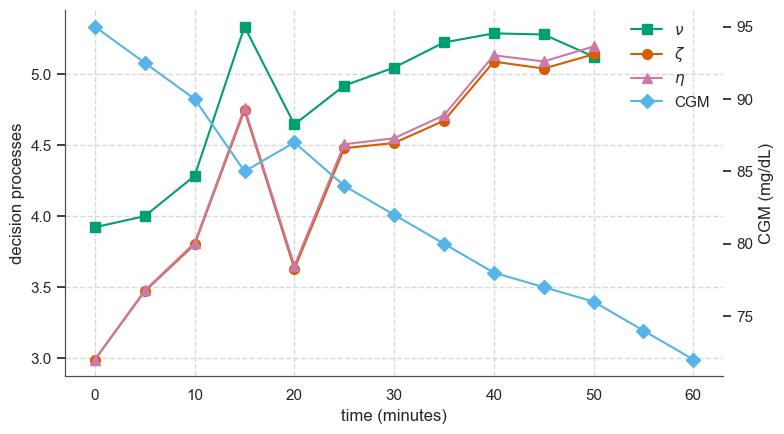

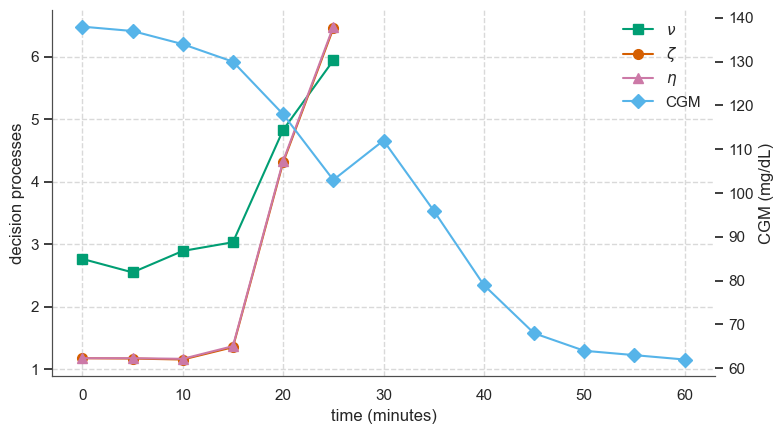

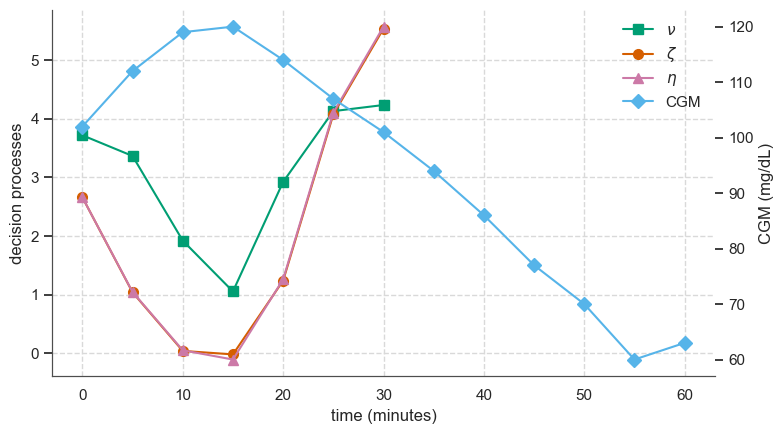

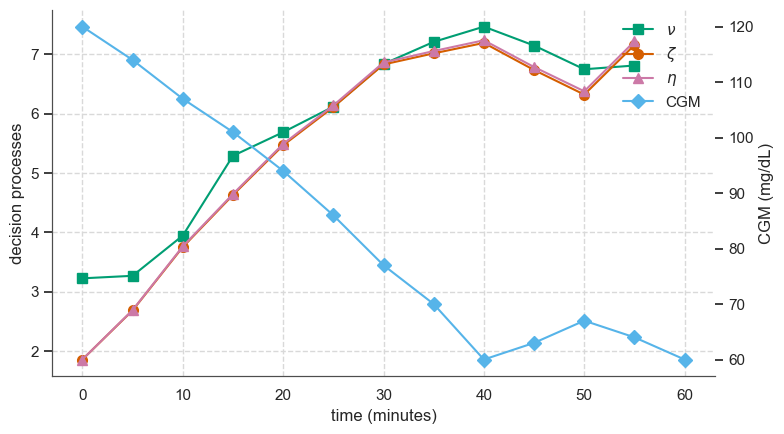

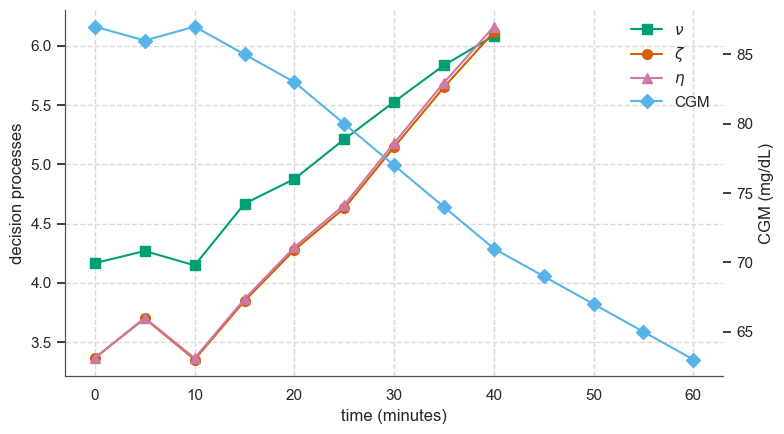

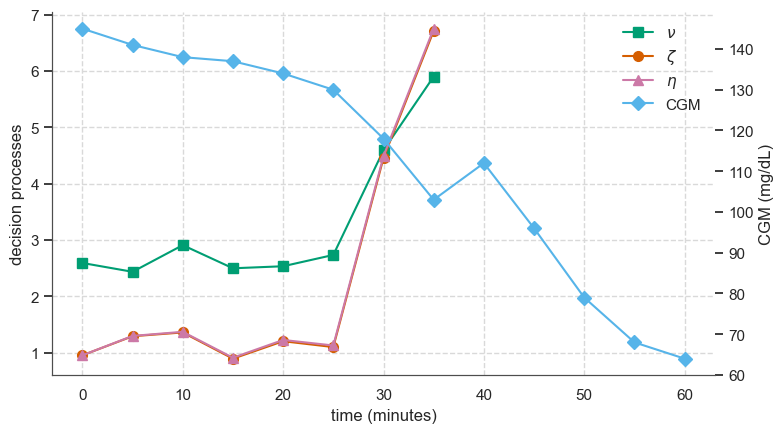

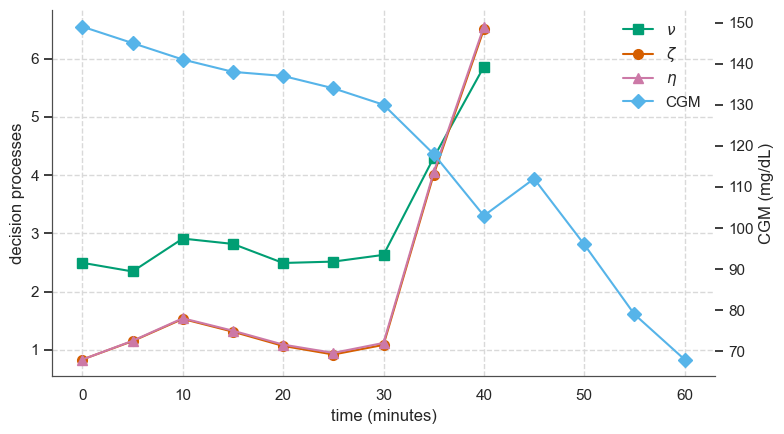

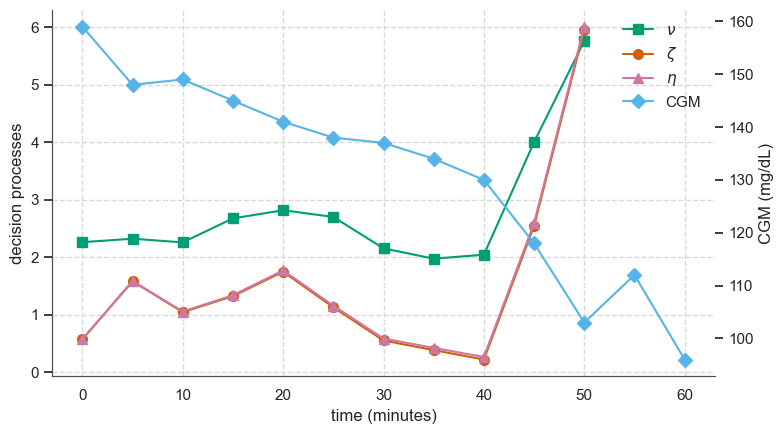

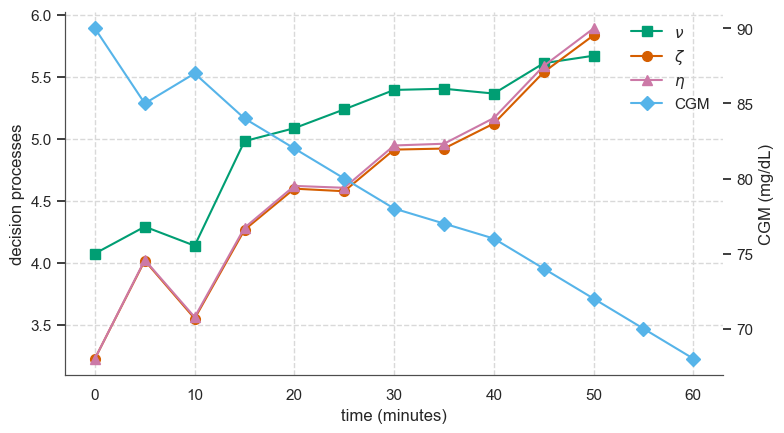

In [16]:
for see_idx in see_seg.idx_sample:
    _ = show_idx(see_idx)

In [17]:
model_ects.eval_performance(dict_loader['test'])

{'cost': 0.6955128312110901,
 'tpr': 0.9356321692466736,
 'fpr': 0.20282626152038574,
 'es1': 0.006001029629260302}

idx 1563 decision 1.0 at 6.0
idx 1561 decision 0.0 at 11.0
idx 1570 decision 1.0 at 10.0


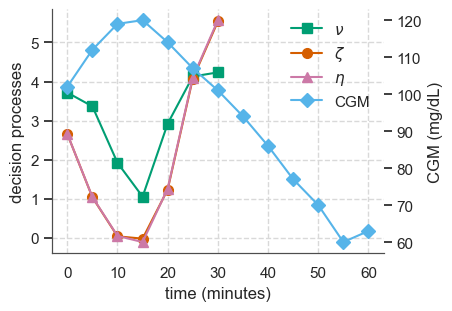

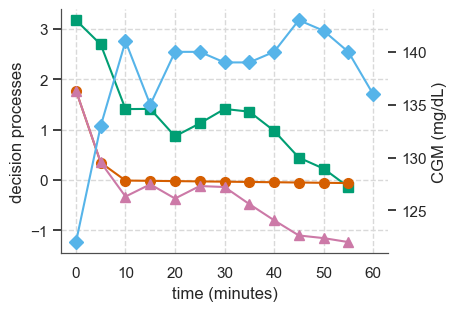

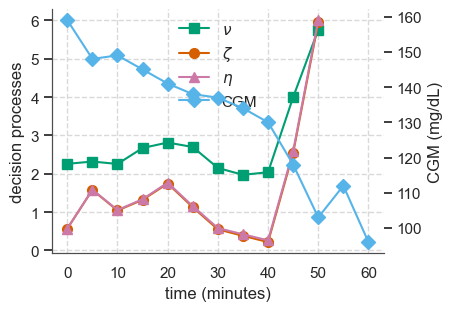

In [18]:
see_idx = 1563
see_fig = show_idx(see_idx)
ggsave_py(see_fig, f"cgm_traj_{see_idx}.pdf", width=4,height=3)

see_idx = 1561
see_fig = show_idx(see_idx, 'none')
ggsave_py(see_fig, f"cgm_traj_{see_idx}.pdf", width=4,height=3)

see_idx = 1570
see_fig = show_idx(see_idx, legend_loc='upper center')
ggsave_py(see_fig, f"cgm_traj_{see_idx}.pdf", width=4,height=3)